<h2>Amogh Sahore<br>
2547108<br>
Machine Learning ETE</h2>

# Q4: Diabetes disease progression: PCA + Support Vector Regression

## Selected approach and justification

**SVR** is appropriate for a small regression dataset and an RBF kernel can learn non-linear feature-target relationships. Its `C` and `epsilon` parameters regularise the fit. SVR depends on distances, so standardisation is essential. **PCA** is appropriate because the ten predictors are numeric and may be correlated: it produces orthogonal components and can discard low-variance directions.

Scaling and PCA are inside each pipeline, so they are fitted only on the training portion of every cross-validation fold. This prevents data leakage.

## 1. Imports and setup

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## 2. Load the dataset

In [3]:
RANDOM_STATE = 42
diabetes = load_diabetes(as_frame=True)
raw_data = diabetes.frame.rename(columns={'target': 'disease_progression'}).copy()


## 3. Check data types and missing values

In [4]:
#Checking for missing values
print(f'Raw dataset shape: {raw_data.shape}')
print('\nData types:')
display(raw_data.dtypes.to_frame('dtype'))
missing = raw_data.isna().sum()
quality_report = pd.DataFrame({'missing_values': missing, 'missing_%': (missing / len(raw_data) * 100).round(2)})
display(quality_report)
duplicate_count = raw_data.duplicated().sum()
print(f'Duplicate complete rows: {duplicate_count}')


Raw dataset shape: (442, 11)

Data types:


,dtype
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64


,missing_values,missing_%
age,0,0.0
sex,0,0.0
bmi,0,0.0
bp,0,0.0
s1,0,0.0
s2,0,0.0
s3,0,0.0
s4,0,0.0
s5,0,0.0
s6,0,0.0


Duplicate complete rows: 0


## 4. Check and handle duplicate rows

In [5]:
# Handle duplicates before splitting. No rows are expected to be removed, but this is reproducible cleaning.
data = raw_data.drop_duplicates().reset_index(drop=True)
print(f'Shape after duplicate handling: {data.shape}')
print('Missing values are handled with median imputation inside both pipelines (fitted only on each training fold).')

X = data.drop(columns='disease_progression')
y = data['disease_progression']


Shape after duplicate handling: (442, 11)
Missing values are handled with median imputation inside both pipelines (fitted only on each training fold).


## 5. Exploratory data analysis

In [6]:
display(X.head())
display(data.describe().T[['mean', 'std', 'min', 'max']])


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,mean,std,min,max
age,-2.511817e-19,0.047619,-0.107226,0.110727
sex,1.230790e-17,0.047619,-0.044642,0.050680
bmi,-2.245564e-16,0.047619,-0.090275,0.170555
bp,-4.797570e-17,0.047619,-0.112399,0.132044
s1,-1.381499e-17,0.047619,-0.126781,0.153914
s2,3.918434e-17,0.047619,-0.115613,0.198788
s3,-5.777179e-18,0.047619,-0.102307,0.181179
s4,-9.042540e-18,0.047619,-0.076395,0.185234
s5,9.268604e-17,0.047619,-0.126097,0.133597
s6,1.130318e-17,0.047619,-0.137767,0.135612


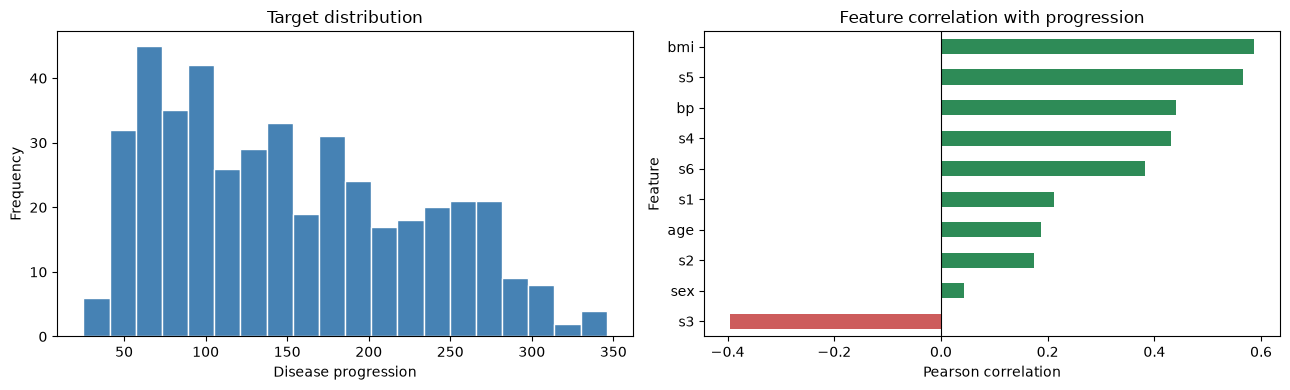

In [7]:
# EDA: target distribution and Pearson association of each predictor with progression
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y, bins=20, edgecolor='white', color='steelblue')
axes[0].set(title='Target distribution', xlabel='Disease progression', ylabel='Frequency')
target_corr = data.corr(numeric_only=True)['disease_progression'].drop('disease_progression').sort_values()
target_corr.plot.barh(ax=axes[1], color=np.where(target_corr >= 0, 'seagreen', 'indianred'))
axes[1].set(title='Feature correlation with progression', xlabel='Pearson correlation', ylabel='Feature')
axes[1].axvline(0, color='black', lw=.8)
plt.tight_layout(); plt.show()


## 6. Create the training and test sets

In [8]:
# A fixed split gives an honest final test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print(f'Predictors: {X.shape[1]}; training rows: {len(X_train)}; test rows: {len(X_test)}')


Predictors: 10; training rows: 353; test rows: 89


## 7. PCA diagnostic

In [9]:
# PCA diagnostics are fitted on training data only
X_train_imputed = SimpleImputer(strategy='median').fit_transform(X_train)
X_train_scaled = StandardScaler().fit_transform(X_train_imputed)
pca_diagnostic = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_diagnostic.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)
print(f'Components retaining at least 95% training variance: {n_components_95} / {X.shape[1]}')


Components retaining at least 95% training variance: 8 / 10


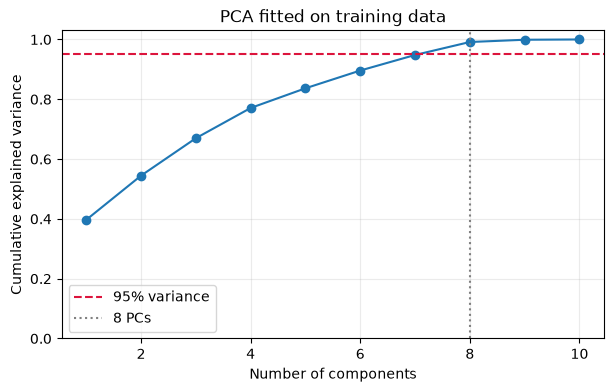

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(.95, color='crimson', ls='--', label='95% variance')
plt.axvline(n_components_95, color='gray', ls=':', label=f'{n_components_95} PCs')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA fitted on training data'); plt.ylim(0, 1.03); plt.grid(alpha=.25); plt.legend(); plt.show()


## 8. Configure cross-validation and parameters

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
svr_parameters = {'svr__kernel': ['rbf'], 'svr__C': [1, 10, 30, 100], 'svr__epsilon': [.05, .1, .2], 'svr__gamma': ['scale', .03, .1]}


## 9. Baseline SVR pipeline

In [12]:
baseline_search = GridSearchCV(
    Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('svr', SVR())]), svr_parameters,
    scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1
)


## 10. PCA plus SVR pipeline

In [13]:
pca_search = GridSearchCV(
    Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('pca', PCA(svd_solver='full')), ('svr', SVR())]),
    {**svr_parameters, 'pca__n_components': [.80, .90, .95]},
    scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1
)


## 11. Evaluation function

In [14]:
def evaluate(label, search):
    t0 = time.perf_counter(); search.fit(X_train, y_train); fit_time = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = search.predict(X_test); predict_time = (time.perf_counter() - t0) * 1000
    return {'Model': label, 'CV RMSE': -search.best_score_, 'Test RMSE': mean_squared_error(y_test, pred)**.5,
            'Test MAE': mean_absolute_error(y_test, pred), 'Test R²': r2_score(y_test, pred),
            'Fit time (s)': fit_time, 'Prediction time (ms)': predict_time, 'Best parameters': search.best_params_}, pred


## 12. Fit and compare the models

In [15]:
baseline_result, baseline_pred = evaluate(
    'StandardScaler + SVR', baseline_search
)
print(f"Baseline best parameters: {baseline_result['Best parameters']}")


Baseline best parameters: {'svr__C': 30, 'svr__epsilon': 0.2, 'svr__gamma': 0.03, 'svr__kernel': 'rbf'}


In [16]:
pca_result, pca_pred = evaluate(
    'StandardScaler + PCA + SVR', pca_search
)
print(f"PCA + SVR best parameters: {pca_result['Best parameters']}")


PCA + SVR best parameters: {'pca__n_components': 0.9, 'svr__C': 30, 'svr__epsilon': 0.2, 'svr__gamma': 0.03, 'svr__kernel': 'rbf'}


### Performance and cost comparison

In [17]:
results = pd.DataFrame([baseline_result, pca_result])
display(results.drop(columns='Best parameters').round(3))


,Model,CV RMSE,Test RMSE,Test MAE,Test R²,Fit time (s),Prediction time (ms)
0,StandardScaler + SVR,56.061,52.470,41.227,0.480,10.755,5.166
1,StandardScaler + PCA + SVR,55.815,52.207,41.190,0.486,2.629,6.762


## 13. Actual versus predicted test values

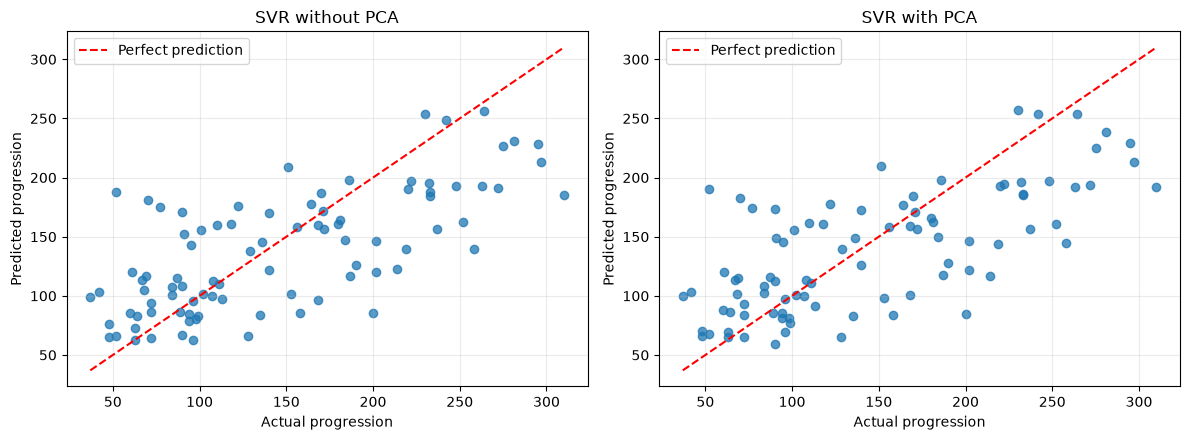

In [18]:
# Predictions should lie close to the red diagonal
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pred, title in zip(axes, [baseline_pred, pca_pred], ['SVR without PCA', 'SVR with PCA']):
    ax.scatter(y_test, pred, alpha=.75)
    limits = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(limits, limits, 'r--', label='Perfect prediction')
    ax.set(xlabel='Actual progression', ylabel='Predicted progression', title=title)
    ax.grid(alpha=.25); ax.legend()
plt.tight_layout(); plt.show()

## 14. Interpret PCA feature loadings

Selected PCA: 7 components; retained variance = 94.8%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
age,0.210,0.114,0.424,0.488,0.676,-0.246,-0.065
sex,0.160,-0.403,-0.107,0.683,-0.346,0.067,-0.010
bmi,0.312,-0.123,0.238,-0.443,-0.061,-0.420,-0.443
bp,0.253,-0.045,0.558,0.060,-0.565,-0.210,0.159
s1,0.355,0.544,-0.160,0.066,-0.125,0.024,0.096
s2,0.355,0.407,-0.353,0.137,-0.125,-0.116,-0.276
s3,-0.274,0.566,0.291,0.106,-0.197,0.143,0.020
s4,0.432,-0.141,-0.356,-0.038,0.087,-0.064,0.068
s5,0.383,-0.019,0.110,-0.230,0.139,0.153,0.731
s6,0.329,-0.073,0.261,-0.084,0.058,0.808,-0.386


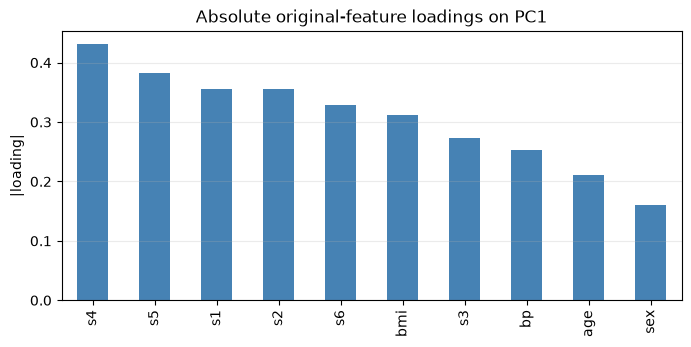

In [19]:
# PCA loadings connect components back to the original clinical variables
fitted_pca = pca_search.best_estimator_.named_steps['pca']
loadings = pd.DataFrame(fitted_pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(fitted_pca.n_components_)])
print(f'Selected PCA: {fitted_pca.n_components_} components; retained variance = {fitted_pca.explained_variance_ratio_.sum():.1%}')
display(loadings.round(3))
loadings['PC1'].abs().sort_values(ascending=False).plot.bar(figsize=(8, 3.5), color='steelblue')
plt.title('Absolute original-feature loadings on PC1'); plt.ylabel('|loading|'); plt.grid(axis='y', alpha=.25); plt.show()

## Conclusion

Compare the test RMSE and R² values in the table. Use PCA + SVR only if it gives lower RMSE, or similar RMSE with fewer components. PCA may reduce computation, but it also makes the model harder to relate to individual clinical variables. For this small 10-feature dataset, standardised SVR is preferable when PCA does not improve the test result.